# Actividad 1: Primeros pasos con Python

Esta actividad usa Python para **abrir, limpiar, transformar, unir y graficar** tres series de Bolivia:

| archivo | qué es | frecuencia |
|---|---|---|
| `gdp.csv` | PIB real de Bolivia (INE, medidas de volumen encadenadas, referencia 2017, millones de bolivianos) | trimestral |
| `ntl.csv` | Luces nocturnas (NASA Black Marble, VNP46A2): radiancia media sobre el territorio boliviano | diaria |
| `eia_brent.xlsx` | Precio spot del petróleo Brent (EIA, dólares por barril) | diaria |

Al terminar se han desarrollado estas habilidades:

1. Abrir un archivo **CSV**;
2. Abrir un archivo **Excel (XLSX)**, incluso uno con filas de título;
3. **Estadísticas descriptivas** básicas;
4. **Limpieza** de datos (filtrar, seleccionar columnas, valores faltantes);
5. **Remuestreo** (*resample*): pasar de datos diarios a trimestrales;
6. **Unión** (*merge*) de varias series por fecha;
7. **Reestructuración** (*reshape*): formato ancho ↔ largo;
8. **Gráficos**, en niveles y en tasas de crecimiento.

### Cómo usar este cuaderno

- Los datos están en la carpeta `data/` del proyecto. Desde este cuaderno la ruta es `../data/` (`..` significa "subir una carpeta").
- Una celda se ejecuta con **Shift + Enter**. Ejecute las celdas **en orden**, de arriba hacia abajo. El orden afecta el producto.
- Donde vea `<SU CÓDIGO AQUÍ: ...>` debe escribir el código que falta. Los comentarios (líneas que empiezan con `#`) dan una pista.
- Si algo se rompe, *Kernel → Restart & Run All* vuelve a empezar desde cero.

In [69]:
# Verifique que esta celda corre sin errores.
# Si falla, vuelva a act0_env_check.ipynb: el entorno no está bien instalado.

import pandas as pd                # pandas: la librería de tablas de datos. "pd" es su alias
import matplotlib.pyplot as plt    # matplotlib: la librería de gráficos

print("pandas", pd.__version__)

pandas 2.3.3


---
## Python básico

Repaso del lenguaje de Python: **tipos de datos**, **operaciones**, **condicionales**, **colecciones**, **bucles** y **funciones**. Ejecute cada celda y lea el resultado.

### Primer programa

`print()` muestra en pantalla lo que se le pase.

In [70]:
print("¡Hola, Bolivia!")
print(2 + 5)

¡Hola, Bolivia!
7


### Variables y tipos de datos

Una **variable** es un nombre que guarda un valor. Se crea con `=`. Python deduce el **tipo** solo:

| tipo | qué guarda | ejemplo |
|---|---|---|
| `int` | números enteros | `2025` |
| `float` | números con decimales | `0.035` |
| `str` | texto (*string*), entre comillas | `"Bolivia"` |
| `bool` | verdadero o falso | `True`, `False` |

`type()` dice de qué tipo es una variable.

In [71]:
pais = "Bolivia"           # str
anio = 2024                # int
pib = 78_258.3             # float: PIB real 2025T1, millones de Bs. (el _ sólo facilita la lectura)
es_trimestral = True       # bool

print(pais, anio, pib, es_trimestral)
print(type(pais), type(anio), type(pib), type(es_trimestral))

Bolivia 2024 78258.3 True
<class 'str'> <class 'int'> <class 'float'> <class 'bool'>


Las variables declaradas se quedan guardadas en la memoria RAM

In [72]:
anio

2024

Hasta que son reemplazadas

In [73]:
anio = anio + 1
print(anio)

2025


### Texto con formato (*f-strings*)

Una `f` antes de las comillas permite meter variables dentro del texto con `{}`. Después de `:` se indica el formato: `.1f` = un decimal, `,.0f` = separador de miles y sin decimales.

In [74]:
crecimiento = -0.0167

print(f"El PIB de {pais} en {anio}T1 fue de {pib:,.0f} millones de Bs.")
print(f"Varió {crecimiento * 100:.1f}% respecto al mismo trimestre de 2024.")

El PIB de Bolivia en 2025T1 fue de 78,258 millones de Bs.
Varió -1.7% respecto al mismo trimestre de 2024.


### Operaciones aritméticas

`+` suma, `-` resta, `*` multiplica, `/` divide, `**` potencia. La tasa de crecimiento entre dos trimestres es `actual / anterior − 1`.

In [75]:
pib_t1 = 78_258.3     # 2025T1
pib_t2 = 86_588.5     # 2025T2

crec = pib_t2 / pib_t1 - 1
print(f"El PIB creció {round(crec * 100, 2)}% entre el T1 y el T2 de 2025.")

El PIB creció 10.64% entre el T1 y el T2 de 2025.


### Condicionales: `if`, `elif`, `else`

Los **operadores de comparación** (`>`, `<`, `>=`, `<=`, `==` igual, `!=` distinto, `in`) devuelven `True` o `False`. `if` ejecuta un bloque sólo si la condición es verdadera.

**La sangría importa**: las líneas que pertenecen al `if` van corridas 4 espacios a la derecha.

In [76]:
crec_pib = -1.5   # en %

if crec_pib >= 3:
    print("Crecimiento fuerte")
elif crec_pib >= 1:
    print("Crecimiento moderado")
elif crec_pib >= 0:
    print("Estancamiento")
else:
    print("Recesión")

print("Fin del programa.")   # sin sangría: se ejecuta siempre

Recesión
Fin del programa.


### Colecciones de datos

| estructura | ejemplo | característica |
|---|---|---|
| **list** | `[2023, 2024, 2025]` | ordenada, modificable |
| **tuple** | `(2023, 2024, 2025)` | ordenada, **no** modificable |
| **dictionary** | `{"anio": 2025, "pib": 78258}` | pares **clave: valor** |
| **set** | `{2023, 2024, 2025}` | sin orden, sin repetidos |

In [77]:
anios = [2023, 2024, 2025]                          # lista
trimestre = (2025, 1)                               # tupla
dato = {"pais": "Bolivia", "anio": 2025, "pib": 78_258.3}   # diccionario
monedas = {"BOB", "USD", "BOB"}                     # conjunto: el BOB repetido desaparece

print(anios, trimestre)
print(dato["pib"])        # en un diccionario se accede por la CLAVE
print(monedas)

[2023, 2024, 2025] (2025, 1)
78258.3
{'BOB', 'USD'}


### Listas

Se pueden escribir directamente, construir con `.append()` o generar con `range()`.

In [78]:
anios = [2021, 2022, 2023, 2024, 2025]

pib_serie = []                 # lista vacía
pib_serie.append(80_693.8)     # 2024T4. .append() agrega un elemento al final
pib_serie.append(78_258.3)     # 2025T1

trimestres = list(range(1, 5))   # range(1, 5) va de 1 a 4: el final NO se incluye

print(anios)
print(pib_serie)
print(trimestres)

[2021, 2022, 2023, 2024, 2025]
[80693.8, 78258.3]
[1, 2, 3, 4]


Se accede a los elementos por **posición**, que **empieza en 0**. Los negativos cuentan desde el final. `[inicio:fin]` extrae un tramo (*slice*), sin incluir `fin`.

In [79]:
print(anios[0])      # el primero
print(anios[-1])     # el último
print(anios[1:3])    # posiciones 1 y 2
print(len(anios))    # cuántos elementos tiene

2021
2025
[2022, 2023]
5


### Bucles

`for` recorre una secuencia, un elemento a la vez:

In [80]:
for a in anios:
    print(a)

2021
2022
2023
2024
2025


`while` repite mientras una condición sea verdadera. Cuidado: si la condición nunca se vuelve falsa, el bucle no termina (se detiene con el botón ■ de Jupyter).

In [81]:
contador = 0
while contador < 4:
    print(f"Trimestre {contador + 1}")
    contador += 1        # igual que: contador = contador + 1

Trimestre 1
Trimestre 2
Trimestre 3
Trimestre 4


### Bucles con condicionales

`enumerate()` entrega a la vez la **posición** y el **valor** de cada elemento. Estas son las variaciones interanuales (%) del PIB boliviano de 2020:

In [82]:
crec_2020 = [-4.6, -25.9, -16.2, -2.7]     # 2020T1 a 2020T4

for i, g in enumerate(crec_2020):
    if g < 0:
        print(f"T{i + 1}: contracción ({g}%)")
    else:
        print(f"T{i + 1}: crecimiento ({g}%)")

T1: contracción (-4.6%)
T2: contracción (-25.9%)
T3: contracción (-16.2%)
T4: contracción (-2.7%)


### Listas por comprensión

Una forma compacta de **construir una lista a partir de otra**: reemplaza un bucle `for` en una sola línea.

In [83]:
pib_millones = [78_258.3, 86_588.5, 84_754.5, 79_771.4]    # 2025, millones de Bs.

# forma larga
pib_miles_mill = []
for p in pib_millones:
    pib_miles_mill.append(p / 1000)

print(pib_miles_mill)

# por comprensión (mismo resultado)
pib_miles_mill = [p / 1000 for p in pib_millones]

print(pib_miles_mill)

[78.2583, 86.5885, 84.7545, 79.7714]
[78.2583, 86.5885, 84.7545, 79.7714]


### Funciones

Una **función** es un bloque de código reutilizable. Se define con `def`, recibe **argumentos** y devuelve un resultado con `return`. El texto entre `""" """` la documenta.

In [84]:
def crecimiento_anualizado(crec_trim):
    """Convierte una tasa trimestral (%) en su equivalente anual (%)."""
    return ((1 + crec_trim / 100) ** 4 - 1) * 100

print(f"Anualizado: {crecimiento_anualizado(0.875):.2f}%")

Anualizado: 3.55%


### Del diccionario a la tabla: el DataFrame

Un **DataFrame** de `pandas` es una tabla. Una forma de crearlo es con un diccionario: cada **clave** es una columna y cada **lista** sus valores. En el resto del cuaderno no escribiremos los datos a mano: los **leeremos de archivos**.

In [85]:
datos = {
    "trimestre": ["2025T1", "2025T2", "2025T3", "2025T4"],
    "pib":       [78_258.3, 86_588.5, 84_754.5, 79_771.4],
}
df = pd.DataFrame(datos)
df

,trimestre,pib
0,2025T1,78258.3
1,2025T2,86588.5
2,2025T3,84754.5
3,2025T4,79771.4


---
## Abrir un archivo CSV: PIB

`pd.read_csv()` convierte el archivo en **DataFrame**: una tabla con filas, columnas y un **índice** (las etiquetas de las filas). En series de tiempo conviene que el índice sea la **fecha**.

In [86]:
df_gdp = pd.read_csv('../data/gdp.csv',   # ruta relativa a este cuaderno
                     index_col='date',    # usar la columna 'date' como índice (en vez de 0, 1, 2, ...)
                     parse_dates=True)    # convertir ese índice a fechas de verdad (datetime)

df_gdp.tail(5)   # las últimas 5 filas

,gdp,gdp_construccion
date,,
2024-12-01,80693.838524,5274.054309
2025-03-01,78258.329648,3983.533226
2025-06-01,86588.461702,4336.750820
2025-09-01,84754.453070,4372.829183
2025-12-01,79771.428778,4342.676900


Antes de hacer cualquier cosa, **mire los datos**. Tres preguntas: ¿cuántas filas y columnas hay? ¿de qué tipo es cada columna? ¿hay valores faltantes?

In [87]:
print(df_gdp.shape)      # (filas, columnas)
df_gdp.info()            # tipo de cada columna y cuántos valores NO faltantes tiene

(36, 2)
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 36 entries, 2017-03-01 to 2025-12-01
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gdp               36 non-null     float64
 1   gdp_construccion  36 non-null     float64
dtypes: float64(2)
memory usage: 864.0 bytes


El archivo trae dos columnas: el PIB total (`gdp`) y el PIB de la construcción (`gdp_construccion`). Aquí sólo usaremos el total.

Con **doble corchete** `df[['columna']]` el resultado sigue siendo un **DataFrame**; con corchete simple `df['columna']` sería una **Series** (una sola columna, sin tabla alrededor). Para unir tablas más adelante nos conviene el DataFrame.

In [88]:
df_gdp = df_gdp[['gdp']]
df_gdp.head(5)   # las primeras 5 filas

,gdp
date,
2017-03-01,75234.208684
2017-06-01,80176.521663
2017-09-01,82560.637203
2017-12-01,79387.240057
2018-03-01,77481.321025


**Observe las fechas.** El trimestre 2017T1 aparece como `2017-03-01`, el 2017T2 como `2017-06-01`: cada trimestre está fechado el **primer día de su último mes**. Es la convención de todo este proyecto. Recuérdela: volverá a aparecer en la sección *Combinar datos*.

---
## Abrir un archivo Excel: el precio del petróleo

`pd.read_excel()` funciona como `read_csv()`, pero un libro de Excel puede tener **varias hojas**, y a menudo tiene **filas de título** encima de los datos.

`eia_brent.xlsx` reproduce el formato con que la EIA (la agencia de energía de EE.UU.) publica el precio del Brent. Primero veamos qué hojas tiene:

In [89]:
libro = pd.ExcelFile('../data/eia_brent.xlsx')
libro.sheet_names          # lista de hojas del libro

['Contents', 'Data 1']

La primera hoja, `Contents`, es sólo una portada. Los datos están en `Data 1`. Leamos esa hoja **sin más opciones** a ver qué pasa:

In [90]:
pd.read_excel('../data/eia_brent.xlsx', sheet_name='Data 1').head(5)

,Back to Contents,Data 1: Europe Brent Spot Price FOB (Dollars per Barrel)
0,Sourcekey,RBRTE
1,Date,Europe Brent Spot Price FOB (Dollars per Barrel)
2,1987-05-20 00:00:00,18.63
3,1987-05-21 00:00:00,18.45
4,1987-05-22 00:00:00,18.55


No quedó bien: las dos primeras filas son **títulos**, no datos, y pandas usó la primera como encabezado. El encabezado verdadero (`Date`, `Europe Brent ...`) está en la **tercera** fila.

La solución es `skiprows=2`: saltar las dos primeras filas.

**COMPLETE**: lea la hoja `Data 1` saltando 2 filas y usando la primera columna como índice (`index_col=0`).

In [91]:
df_brent = pd.read_excel('../data/eia_brent.xlsx', sheet_name='Data 1', skiprows=2, index_col=0)

df_brent.head(5)

,Europe Brent Spot Price FOB (Dollars per Barrel)
Date,
1987-05-20,18.63
1987-05-21,18.45
1987-05-22,18.55
1987-05-25,18.60
1987-05-26,18.63


El nombre de la columna es larguísimo. Cambiémoslo con `.rename()`, que recibe un **diccionario** `{nombre_viejo: nombre_nuevo}`:

In [92]:
df_brent = df_brent.rename(columns={'Europe Brent Spot Price FOB (Dollars per Barrel)': 'brent'})
df_brent.index.name = 'date'      # el mismo nombre de índice que las otras series

print(df_brent.index.dtype)       # debe decir datetime64: Excel ya guardaba fechas
df_brent.tail(5)

datetime64[ns]


,brent
date,
2026-09-09,109.51
2026-09-10,120.98
2026-09-11,118.06
2026-09-14,121.25
2026-09-15,130.80


---
## Luces nocturnas

`ntl.csv` resume, **día por día**, las imágenes satelitales nocturnas de la NASA sobre Bolivia. Las luces nocturnas se usan como indicador de actividad económica porque se observan casi en tiempo real, mucho antes de que se publique el PIB.

**COMPLETE**: cargue `ntl.csv` igual que cargó el PIB.

In [93]:
df_ntl = pd.read_csv('../data/ntl.csv', index_col='date', parse_dates=True)

df_ntl.head(10)

,ntl_mean,ntl_sum,ntl_n,ntl_tiles
date,,,,
2012-01-19,0.352537,1.867804e+06,5298172,4
2012-01-20,0.681297,3.609630e+06,5298172,4
2012-01-21,0.341563,1.809658e+06,5298172,4
2012-01-22,0.321885,1.705401e+06,5298172,4
2012-01-23,0.285101,1.510515e+06,5298172,4
2012-01-24,0.382284,2.025404e+06,5298172,4
2012-01-25,0.268008,1.419950e+06,5298172,4
2012-01-26,0.270621,1.433798e+06,5298172,4
2012-01-27,0.317984,1.684736e+06,5298172,4


Las columnas:

| columna | significado |
|---|---|
| `ntl_mean` | radiancia media de los píxeles de Bolivia ese día — **la que usaremos** |
| `ntl_sum` | suma de la radiancia de todos los píxeles |
| `ntl_n` | número de píxeles usados |
| `ntl_tiles` | cuántas de las 4 "piezas" satelitales que cubren Bolivia había ese día |

---
## Estadísticas descriptivas

`.describe()` resume cada columna numérica: número de observaciones (`count`), media, desviación estándar, mínimo, cuartiles y máximo.

In [94]:
df_ntl.describe()

,ntl_mean,ntl_sum,ntl_n,ntl_tiles
count,5253.000000,5.253000e+03,5.253000e+03,5253.000000
mean,0.484757,2.566083e+06,5.290461e+06,3.995050
std,0.194220,1.029530e+06,1.903449e+05,0.111992
min,0.070899,2.663231e+04,3.756350e+05,1.000000
25%,0.339459,1.797914e+06,5.298172e+06,4.000000
50%,0.451224,2.388860e+06,5.298172e+06,4.000000
75%,0.596069,3.157337e+06,5.298172e+06,4.000000
max,1.537984,8.148502e+06,5.298172e+06,4.000000


También se pueden pedir estadísticas una por una. `idxmax()` devuelve **la fecha** en que ocurre el máximo, no el valor.

In [95]:
print("media del Brent          :", round(df_brent['brent'].mean(), 2))
print("mínimo del Brent         :", df_brent['brent'].min(), "el", df_brent['brent'].idxmin().date())
print("máximo del Brent         :", df_brent['brent'].max(), "el", df_brent['brent'].idxmax().date())
print("PIB: primer y último dato:", df_gdp.index.min().date(), "a", df_gdp.index.max().date())

media del Brent          : 54.32
mínimo del Brent         : 9.1 el 1998-12-10
máximo del Brent         : 143.95 el 2008-07-03
PIB: primer y último dato: 2017-03-01 a 2025-12-01


`value_counts()` cuenta cuántas veces aparece cada valor. Úselo para ver cuántos días tienen las 4 piezas completas:

In [96]:
df_ntl['ntl_tiles'].value_counts()

ntl_tiles
4    5241
1       6
3       4
2       2
Name: count, dtype: int64

---
## Limpieza

Algunos días el satélite no cubrió las 4 piezas del mapa. Vamos a filtrar los días usando una **máscara booleana**: una condición de `True` o `False` para cada fila. `df[condición]` conserva sólo las filas `True`.

In [97]:
mascara = df_ntl['ntl_tiles'] == 4        # True si el día tiene las 4 piezas
print("días completos:", mascara.sum(), "de", len(df_ntl))

df_ntl = df_ntl[mascara]
df_ntl.head(5)

días completos: 5241 de 5253


,ntl_mean,ntl_sum,ntl_n,ntl_tiles
date,,,,
2012-01-19,0.352537,1.867804e+06,5298172,4
2012-01-20,0.681297,3.609630e+06,5298172,4
2012-01-21,0.341563,1.809658e+06,5298172,4
2012-01-22,0.321885,1.705401e+06,5298172,4
2012-01-23,0.285101,1.510515e+06,5298172,4


Equivalentemente:

In [98]:
df_ntl = df_ntl[df_ntl['ntl_tiles'] == 4]
df_ntl.head(5)

,ntl_mean,ntl_sum,ntl_n,ntl_tiles
date,,,,
2012-01-19,0.352537,1.867804e+06,5298172,4
2012-01-20,0.681297,3.609630e+06,5298172,4
2012-01-21,0.341563,1.809658e+06,5298172,4
2012-01-22,0.321885,1.705401e+06,5298172,4
2012-01-23,0.285101,1.510515e+06,5298172,4


**COMPLETE**: filtremos las columnas para quedar solo con `ntl_mean`.

In [99]:
df_ntl = df_ntl[['ntl_mean']]
df_ntl.head(5)

,ntl_mean
date,
2012-01-19,0.352537
2012-01-20,0.681297
2012-01-21,0.341563
2012-01-22,0.321885
2012-01-23,0.285101


Dos revisiones más que conviene hacer siempre: **valores faltantes** y **fechas duplicadas**.

In [100]:
print("faltantes por columna:")
print(df_ntl.isna().sum())
print()
print("fechas duplicadas:", df_ntl.index.duplicated().sum())

faltantes por columna:
ntl_mean    0
dtype: int64

fechas duplicadas: 0


Veamos la serie. Los datos diarios son **ruidosos** (nubes, luna, ángulo del satélite): un día aislado dice poco.

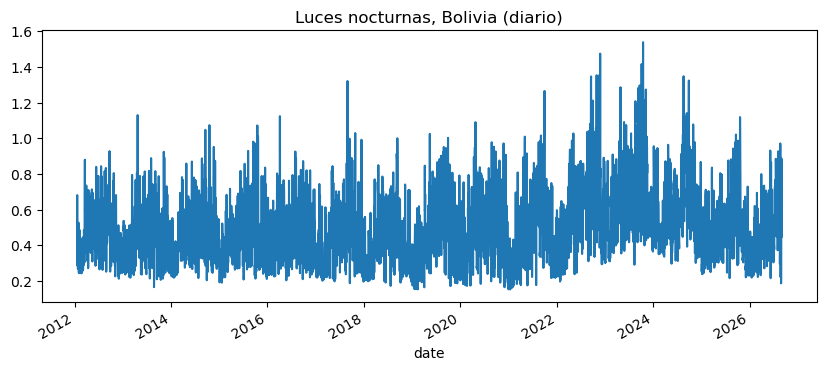

In [101]:
df_ntl.plot(figsize=(10, 4), title='Luces nocturnas, Bolivia (diario)', legend=False)
plt.show()

---
## Remuestreo (*resample*)

Tenemos **dos frecuencias**: las luces y el Brent son **diarios**, el PIB es **trimestral**. No se pueden unir series de distinta frecuencia: primero hay que llevarlas a la misma. Manda la **más lenta**, el PIB.

`.resample(regla)` agrupa las fechas por periodos y luego se elige cómo resumir cada grupo (`.mean()`, `.sum()`, `.last()`...). Reglas útiles:

| regla | periodo | fecha que se asigna |
|---|---|---|
| `'MS'` | mes | primer día del mes |
| `'QS'` | trimestre | primer día del trimestre (1 ene, 1 abr, ...) |
| `'QE'` | trimestre | último día del trimestre (31 mar, 30 jun, ...) |

**COMPLETE**: lleve las luces a frecuencia trimestral con `'QS'`, promediando los días de cada trimestre.

In [102]:
df_ntl_q = df_ntl.resample('QS').mean()
df_ntl_q.tail(8)

,ntl_mean
date,
2024-10-01,0.547314
2025-01-01,0.408785
2025-04-01,0.495403
2025-07-01,0.585972
2025-10-01,0.471774
2026-01-01,0.369191
2026-04-01,0.478107
2026-07-01,0.565739


El promedio trimestral elimina buena parte del ruido:

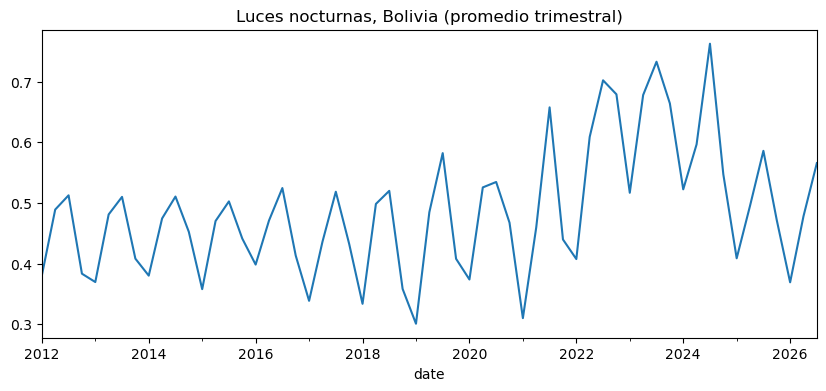

In [103]:
df_ntl_q.plot(figsize=(10, 4), title='Luces nocturnas, Bolivia (promedio trimestral)', legend=False)
plt.show()

**COMPLETE**: haga lo mismo con el Brent.

In [104]:
df_brent_q = df_brent.resample('QS').mean()
df_brent_q.tail(8)

,brent
date,
2024-10-01,74.656094
2025-01-01,75.874603
2025-04-01,68.067049
2025-07-01,69.031231
2025-10-01,63.654219
2026-01-01,80.719841
2026-04-01,102.625902
2026-07-01,91.769074


**Ojo.** Las luces llegan hasta el 1 de septiembre de 2026 y el Brent hasta mediados de septiembre: el trimestre 2026T3 promedia sólo una parte de sus días. En un nowcast real eso es justamente lo que se aprovecha (información parcial del trimestre en curso), pero hay que saberlo.

---
## Combinar datos (*merge*)

Las tres series son trimestrales. Vamos a unirlas por fecha. `.merge()` funciona como un *JOIN* de SQL: con `left_index=True, right_index=True` usa el índice (la fecha) de ambos lados como llave.

In [105]:
df_merge = df_gdp.merge(df_ntl_q, left_index=True, right_index=True)
df_merge = df_merge.merge(df_brent_q, left_index=True, right_index=True)   # se encadena una segunda unión
df_merge

,gdp,ntl_mean,brent
date,,,


**Salió vacío.** Es un problema muy común: las fechas **no coinciden**. Compárelas:

In [106]:
print(df_gdp.index[-3:])
print(df_ntl_q.index[-3:])

DatetimeIndex(['2025-06-01', '2025-09-01', '2025-12-01'], dtype='datetime64[ns]', name='date', freq=None)
DatetimeIndex(['2026-01-01', '2026-04-01', '2026-07-01'], dtype='datetime64[ns]', name='date', freq='QS-JAN')


El PIB está fechado el **primer día del último mes** del trimestre (1 mar, 1 jun, 1 sep, 1 dic), mientras que `resample('QS')` fechó las otras dos series el **primer día del trimestre** (1 ene, 1 abr, ...). Son el mismo trimestre, pero pandas sólo ve fechas distintas.

Hay varias soluciones. Por ejemplo, **mover** las fechas de las luces y del Brent dos meses hacia adelante con `pd.DateOffset(months=2)`, para que 1 ene pase a ser 1 mar.

**COMPLETE**: aplique el desplazamiento al índice del Brent, igual que se hace con las luces.

In [107]:
df_ntl_q.index = df_ntl_q.index + pd.DateOffset(months=2)
df_brent_q.index = df_brent_q.index + pd.DateOffset(months=2)

df_brent_q.tail(3)

,brent
date,
2026-03-01,80.719841
2026-06-01,102.625902
2026-09-01,91.769074


In [108]:
# Ahora las fechas coinciden y la unión sí trae filas
df_merge = df_gdp.merge(df_ntl_q, left_index=True, right_index=True)
df_merge = df_merge.merge(df_brent_q, left_index=True, right_index=True)
df_merge

,gdp,ntl_mean,brent
date,,,
2017-03-01,75234.208684,0.338686,53.594531
2017-06-01,80176.521663,0.435950,49.554063
2017-09-01,82560.637203,0.518551,52.099385
2017-12-01,79387.240057,0.432524,61.396508
2018-03-01,77481.321025,0.333740,66.863492
2018-06-01,85436.468557,0.498397,74.533871
2018-09-01,82898.761356,0.520011,75.070154
2018-12-01,80644.170601,0.358300,68.763871
2019-03-01,80209.913344,0.300941,63.097302


La tabla termina en **2025T4**. Las luces y el Brent llegan a 2026 pero, por omisión, `merge` hace un *inner join*: sólo conserva las fechas presentes **en las tres** series.

Con `how='left'` se conservan todas las fechas de la tabla de la izquierda; con `how='outer'`, todas las de ambas. Las fechas sin dato quedan como `NaN`.

In [109]:
df_outer = df_gdp.merge(df_ntl_q, left_index=True, right_index=True, how='outer')
df_outer.tail(6)     # el PIB de 2026 aún no existe: justamente lo que un nowcast quiere estimar

,gdp,ntl_mean
date,,
2025-06-01,86588.461702,0.495403
2025-09-01,84754.453070,0.585972
2025-12-01,79771.428778,0.471774
2026-03-01,NaN,0.369191
2026-06-01,NaN,0.478107
2026-09-01,NaN,0.565739


---
## Reestructurar (*reshape*): ancho ↔ largo

Una tabla puede estar en dos formatos:

- **wide** (ancho): una fila por fecha y una columna por serie (así está `df_merge`);
- **long** (largo): una fila por cada par (fecha, serie), con una columna que dice *qué serie* es y otra con el *valor*.

Muchas herramientas (bases de datos, algunos gráficos, R) prefieren el formato largo.

`.melt()` pasa de ancho a largo:

In [110]:
df_largo = df_merge.reset_index().melt(id_vars='date',        # la columna que se mantiene
                                        var_name='serie',      # nombre de la nueva columna con los nombres
                                        value_name='valor')    # nombre de la nueva columna con los valores
print(df_largo.shape)
df_largo.head(6)

(108, 3)


,date,serie,valor
0,2017-03-01,gdp,75234.208684
1,2017-06-01,gdp,80176.521663
2,2017-09-01,gdp,82560.637203
3,2017-12-01,gdp,79387.240057
4,2018-03-01,gdp,77481.321025
5,2018-06-01,gdp,85436.468557


`.pivot()` hace lo contrario: de largo a ancho.

**COMPLETE**: reconstruya la tabla ancha con `index='date'`, `columns='serie'` y `values='valor'`.

In [111]:
df_ancho = df_largo.pivot(index='date', columns='serie', values='valor')
df_ancho.head(3)

serie,brent,gdp,ntl_mean
date,,,
2017-03-01,53.594531,75234.208684,0.338686
2017-06-01,49.554063,80176.521663,0.435950
2017-09-01,52.099385,82560.637203,0.518551


Un uso práctico de `pivot_table`: la tabla **año × trimestre** del PIB, la forma en que suelen presentarlo los boletines.

In [112]:
tabla = df_gdp.copy()
tabla['anio'] = tabla.index.year          # año de cada fecha
tabla['trimestre'] = tabla.index.quarter  # trimestre (1 a 4) de cada fecha

tabla.pivot_table(index='anio', columns='trimestre', values='gdp').round(0)

trimestre,1,2,3,4
anio,,,,
2017,75234.0,80177.0,82561.0,79387.0
2018,77481.0,85436.0,82899.0,80644.0
2019,80210.0,86412.0,85874.0,78883.0
2020,76532.0,64029.0,71920.0,76750.0
2021,75109.0,81541.0,81169.0,80419.0
2022,81682.0,85248.0,84141.0,79091.0
2023,81529.0,88308.0,86547.0,82086.0
2024,79584.0,89058.0,85333.0,80694.0
2025,78258.0,86588.0,84754.0,79771.0


---
## Gráficos

Un gráfico con las tres series en niveles no dice mucho: están en **unidades distintas** (millones de bolivianos, radiancia, dólares).

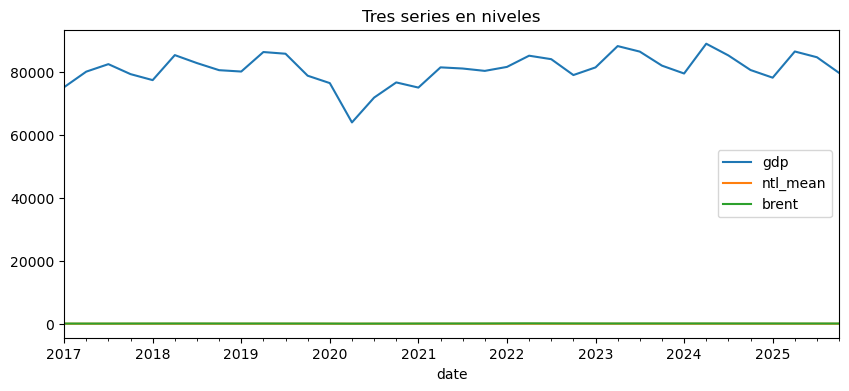

In [113]:
df_merge.plot(figsize=(10, 4), title='Tres series en niveles')
plt.show()

Para generar un panel por serie `subplots=True`:

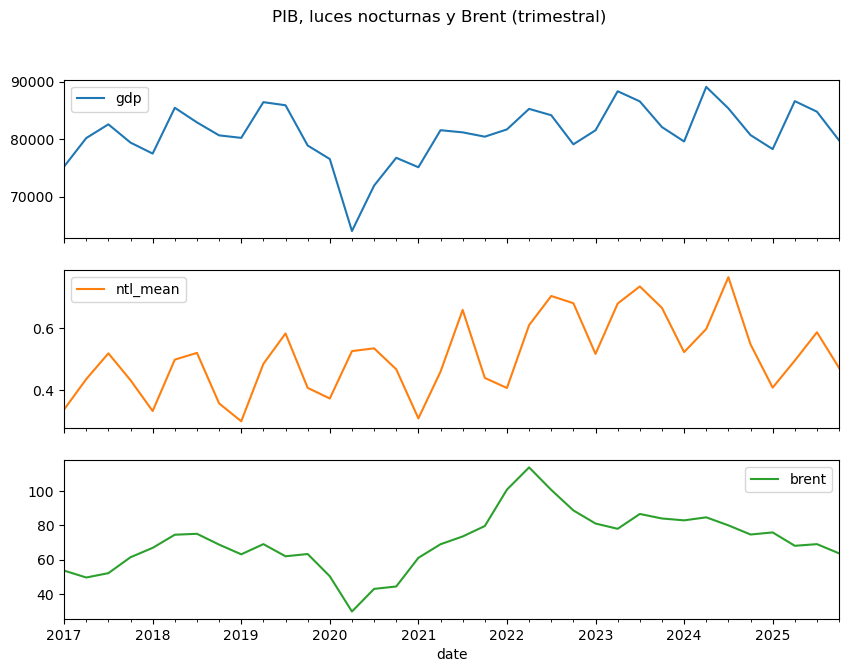

In [114]:
df_merge.plot(subplots=True, figsize=(10, 7), title='PIB, luces nocturnas y Brent (trimestral)')
plt.show()

Para comparar series de distinta escala podemos usar **tasas de variación**.

`.pct_change()` calcula `(actual − anterior) / anterior`.

- `pct_change()` compara con el trimestre anterior (**variación trimestral**). Mezcla estacionalidad: el PIB boliviano cae casi siempre en el primer trimestre.
- `pct_change(4)` compara con el mismo trimestre del año anterior (**variación interanual**). Así se elimina buena parte de la estacionalidad.

In [115]:
df_qoq = df_merge.pct_change() * 100      # variación trimestral, en %
df_qoq.head(5)                            # la primera fila es NaN: no hay trimestre anterior

,gdp,ntl_mean,brent
date,,,
2017-03-01,NaN,NaN,NaN
2017-06-01,6.569236,28.717938,-7.538957
2017-09-01,2.973583,18.947390,5.136455
2017-12-01,-3.843717,-16.589819,17.844977
2018-03-01,-2.400788,-22.839019,8.904389


**COMPLETE**: calcule la variación **interanual** y grafíquela.

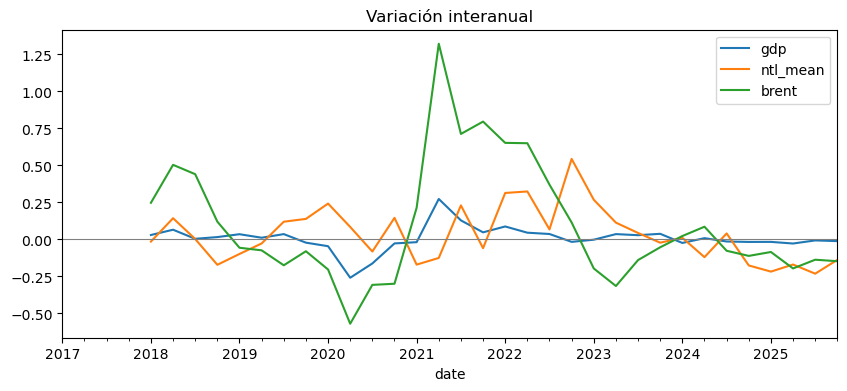

In [116]:
df_yoy = df_merge.pct_change(4)

df_yoy.plot(figsize=(10, 4), title='Variación interanual')
plt.axhline(0, color='grey', lw=0.8)
plt.show()

Algunas preguntas para comentar:

- ¿Dónde se ve la **caída del COVID** (2020T2)? ¿Las luces nocturnas la registran?
- ¿El Brent se mueve con el PIB boliviano? Bolivia exporta gas, cuyos contratos se han indexado al petróleo.

In [117]:
df_yoy.corr().round(2)

,gdp,ntl_mean,brent
gdp,1.00,0.04,0.78
ntl_mean,0.04,1.00,0.11
brent,0.78,0.11,1.00


La correlación del Brent con el PIB sale alta, y la de las luces nocturnas, casi nula. Antes de concluir nada, **mire el gráfico**: con sólo ~32 trimestres, un único episodio (2020) puede dominar la correlación. Pruebe a calcularla excluyendo 2020 y 2021:

In [118]:
df_yoy[(df_yoy.index.year < 2020) | (df_yoy.index.year > 2021)].corr().round(2)

,gdp,ntl_mean,brent
gdp,1.00,0.34,0.58
ntl_mean,0.34,1.00,0.41
brent,0.58,0.41,1.00



Por eso un nowcast no se apoya en una sola serie: combina muchas y evalúa fuera de muestra, como veremos en las sesiones 5 y 6.